# Feature Selection

This notebook reuses the already preprocessed data from `Preprocessment.ipynb` and applies:
1. Pearson correlation (numeric features vs target)
2. Random Forest feature importance

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier

TARGET_COL = "y"
RANDOM_STATE = 42

In [7]:
X_train = pd.read_csv(Path(r"data/X_train_processed.csv"))
X_test = pd.read_csv(Path(r"data/X_test_processed.csv"))
y_train = pd.read_csv(Path(r"data/y_train.csv"))
y_test = pd.read_csv(Path(r"data/y_test.csv"))

print(f"Train preprocessed shape: {X_train.shape}")
print(f"Test preprocessed shape:  {X_test.shape}")

Train preprocessed shape: (36168, 16)
Test preprocessed shape:  (9043, 16)


## 1) Pearson Correlation

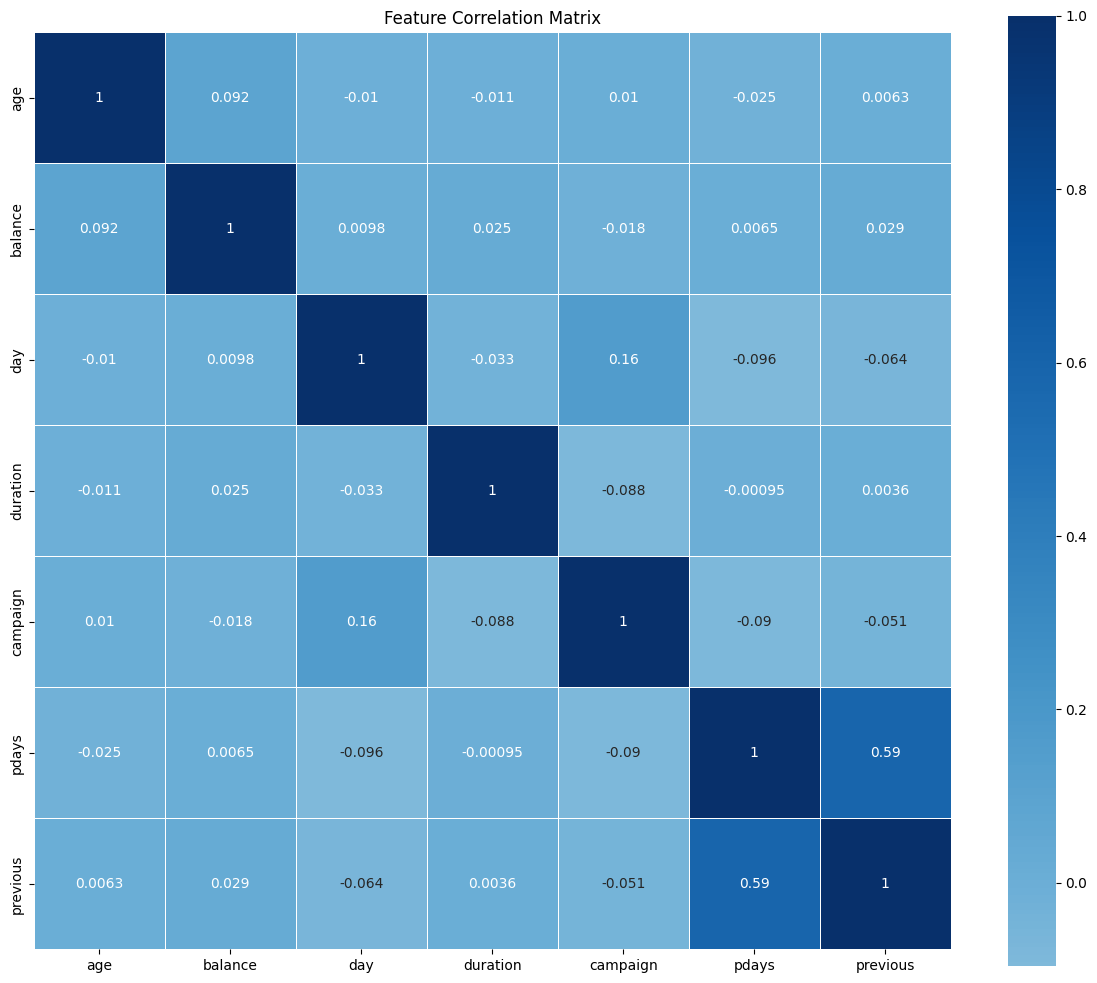

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# correlation matrix between features
corr_map = X_train[numeric_cols].corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_map,
    cmap="Blues",
    center=0,
    square=True,
    annot=True,
    linewidths=0.5
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## 2) Random Forest Importance

In [15]:
# One-hot encode categoricals for Random Forest
X_train_encoded = pd.get_dummies(X_train, drop_first=True)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced",
)
rf.fit(X_train_encoded, y_train)

rf_importance_encoded = pd.Series(rf.feature_importances_, index=X_train_encoded.columns).sort_values(ascending=False)
rf_importance_encoded.head(15)

c:\Users\migue\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


duration            0.361633
balance             0.087048
age                 0.082928
day                 0.074979
poutcome_success    0.042765
pdays               0.036987
campaign            0.036308
housing_yes         0.031451
previous            0.026578
month_may           0.017706
month_mar           0.013599
month_oct           0.012994
loan_yes            0.010721
marital_married     0.010459
month_aug           0.010392
dtype: float64

In [16]:
# Aggregate importance back to original feature names
importance_by_feature = {}

for col in X_train.columns:
    if col in X_train_encoded.columns:
        importance_by_feature[col] = float(rf_importance_encoded[col])
    else:
        matching = [c for c in X_train_encoded.columns if c.startswith(f"{col}_")]
        importance_by_feature[col] = float(rf_importance_encoded[matching].sum()) if matching else 0.0

rf_importance = pd.Series(importance_by_feature).sort_values(ascending=False)
rf_importance_df = pd.DataFrame({
    "rf_importance": rf_importance
})

rf_importance_df.head(15)

,rf_importance
duration,0.361633
month,0.104302
balance,0.087048
age,0.082928
day,0.074979
job,0.054704
poutcome,0.045965
pdays,0.036987
campaign,0.036308
housing,0.031451


In [17]:
TOP_K_RF = 15
selected_by_rf = rf_importance.head(TOP_K_RF).index.tolist()

print(f"Random Forest selected top-{TOP_K_RF} features: {len(selected_by_rf)}")
selected_by_rf

Random Forest selected top-15 features: 15


['duration',
 'month',
 'balance',
 'age',
 'day',
 'job',
 'poutcome',
 'pdays',
 'campaign',
 'housing',
 'previous',
 'marital',
 'education',
 'loan',
 'contact']

## Final Selected Features